In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [5]:
# ===============================
# 1) CARGA Y LIMPIEZA
# ===============================

datos = pd.read_excel('elecciones 2025.xlsx')
datos.columns = datos.columns.str.strip()

for col in ["NombrePais", "NombreDepartamento", "NombreProvincia",
            "NombreMunicipio", "NombreLocalidad", "NombreRecinto"]:
    if col in datos.columns:
        datos[col] = datos[col].astype(str).str.strip()

# -------------------------------
# Columnas de votos (para Y)
# -------------------------------
votos_cols = [
    "AP", "LYP ADN", "APB SUMATE", "LIBRE", "FP",
    "MAS-IPSP", "MORENA", "UNIDAD", "PDC",
    "VotoBlanco", "VotoNuloDirecto", "VotoNuloDeclinacion"
]
votos_cols = [c for c in votos_cols if c in datos.columns]

# ===============================
# 2) TARGET MULTICLASE (Y)
# ===============================
partido_a_codigo = {partido: idx for idx, partido in enumerate(votos_cols)}
codigo_a_partido = {v: k for k, v in partido_a_codigo.items()}
Y = datos[votos_cols].idxmax(axis=1).map(partido_a_codigo).values

# ===============================
# 3) FEATURES (X)
# ===============================
le_pais  = LabelEncoder().fit(datos["NombrePais"])
le_depto = LabelEncoder().fit(datos["NombreDepartamento"])
le_prov  = LabelEncoder().fit(datos["NombreProvincia"])
le_muni  = LabelEncoder().fit(datos["NombreMunicipio"])
le_loc   = LabelEncoder().fit(datos["NombreLocalidad"])
le_rec   = LabelEncoder().fit(datos["NombreRecinto"])

datos["Pais"]          = le_pais.transform(datos["NombrePais"])
datos["Departamento"]  = le_depto.transform(datos["NombreDepartamento"])
datos["Provincia"]     = le_prov.transform(datos["NombreProvincia"])
datos["Municipio"]     = le_muni.transform(datos["NombreMunicipio"])
datos["Localidad"]     = le_loc.transform(datos["NombreLocalidad"])
datos["Recinto"]       = le_rec.transform(datos["NombreRecinto"])

feat_cols = []
for c in [
    "CodigoPais","CodigoDepartamento","CodigoCircunscripcionU","CodigoCircunscripcionE",
    "CodigoProvincia","CodigoSeccion","CodigoLocalidad","CodigoRecinto",
    "NumeroMesa","InscritosHabilitados",
    "Pais","Departamento","Provincia","Municipio","Localidad","Recinto"
]:
    if c in datos.columns:
        feat_cols.append(c)

X = datos[feat_cols].values

print("Shape X:", X.shape, "| Shape Y:", Y.shape)
assert X.shape[0] == Y.shape[0]

# ===============================
# 4) SPLIT
# ===============================
X_train, X_val, y_train, y_val = train_test_split(
    X, Y, test_size=0.20, random_state=42, stratify=Y
)

Shape X: (69279, 16) | Shape Y: (69279,)


In [6]:
class TabularDataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

dataset = {
    'train': TabularDataset(X_train, y_train),
    'val': TabularDataset(X_val, y_val),
}

dataloader = {
    'train': torch.utils.data.DataLoader(dataset['train'], batch_size=32, shuffle=True),
    'val': torch.utils.data.DataLoader(dataset['val'], batch_size=1000, shuffle=False)
}

In [7]:
def softmax(x):
    return torch.exp(x) / torch.exp(x).sum(axis=-1, keepdims=True)

In [8]:
def build_model(D_in=X_train.shape[1], H=16, D_out=len(votos_cols)):
    # Red super simple: Linear → ReLU → Linear
    return torch.nn.Sequential(
        torch.nn.Linear(D_in, H),
        torch.nn.ReLU(),
        torch.nn.Linear(H, D_out)
    )

In [9]:
def fit(model, dataloader, epochs=200, log_each=10, weight_decay=1e-4, early_stopping=20):
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=weight_decay)

    l, acc = [], []
    val_l, val_acc = [], []
    best_acc, step = 0, 0

    for e in range(1, epochs+1):
        _l, _acc = [], []
        model.train()
        for x_b, y_b in dataloader['train']:
            y_pred = model(x_b)
            loss = criterion(y_pred, y_b)
            _l.append(loss.item())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            y_probas = torch.argmax(softmax(y_pred), axis=1)
            _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().detach().numpy()))

        l.append(np.mean(_l))
        acc.append(np.mean(_acc))

        # validación
        model.eval()
        _l, _acc = [], []
        with torch.no_grad():
            for x_b, y_b in dataloader['val']:
                y_pred = model(x_b)
                loss = criterion(y_pred, y_b)
                _l.append(loss.item())
                y_probas = torch.argmax(softmax(y_pred), axis=1)
                _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().numpy()))
        val_l.append(np.mean(_l))
        val_acc.append(np.mean(_acc))

        # guardar mejor modelo
        if val_acc[-1] > best_acc:
            best_acc = val_acc[-1]
            torch.save(model.state_dict(), 'ckpt.pt')
            step = 0
            print(f"Mejor modelo guardado con acc {best_acc:.5f} en epoch {e}")
        else:
            step += 1

        if early_stopping and step > early_stopping:
            print(f"Entrenamiento detenido en epoch {e} por no mejorar en {early_stopping} epochs seguidas")
            break

        if not e % log_each:
            print(f"Epoch {e}/{epochs} loss {l[-1]:.5f} acc {acc[-1]:.5f} "
                  f"val_loss {val_l[-1]:.5f} val_acc {val_acc[-1]:.5f}")

    model.load_state_dict(torch.load('ckpt.pt'))

    return {
        'epoch': list(range(1, len(l)+1)),
        'loss': l, 'acc': acc,
        'val_loss': val_l, 'val_acc': val_acc
    }

In [10]:
# --- Entrenamiento ---
model = build_model()
hist = fit(model, dataloader, early_stopping=20)


Mejor modelo guardado con acc 0.26192 en epoch 1
Mejor modelo guardado con acc 0.30025 en epoch 2
Mejor modelo guardado con acc 0.31116 en epoch 3
Mejor modelo guardado con acc 0.33658 en epoch 4
Mejor modelo guardado con acc 0.34759 en epoch 5
Mejor modelo guardado con acc 0.36753 en epoch 6
Mejor modelo guardado con acc 0.37719 en epoch 7
Mejor modelo guardado con acc 0.39176 en epoch 8
Mejor modelo guardado con acc 0.40036 en epoch 9
Mejor modelo guardado con acc 0.43059 en epoch 10
Epoch 10/200 loss 1.47258 acc 0.41544 val_loss 1.50420 val_acc 0.43059
Mejor modelo guardado con acc 0.46011 en epoch 11
Mejor modelo guardado con acc 0.51882 en epoch 12
Mejor modelo guardado con acc 0.52243 en epoch 19
Epoch 20/200 loss 1.23593 acc 0.52210 val_loss 1.24196 val_acc 0.51306
Mejor modelo guardado con acc 0.52517 en epoch 24
Mejor modelo guardado con acc 0.52596 en epoch 25
Epoch 30/200 loss 1.22150 acc 0.52453 val_loss 1.21242 val_acc 0.52478
Mejor modelo guardado con acc 0.54575 en epoch

In [17]:
model = build_model()
model.load_state_dict(torch.load("ckpt.pt"))
model.eval()

# Accuracy de validación
with torch.no_grad():
    x = torch.tensor(X_val, dtype=torch.float32)
    logits = model(x)
    preds = torch.argmax(logits, axis=1).numpy()

from sklearn.metrics import accuracy_score
val_acc = accuracy_score(y_val, preds)

print("Precicion:", val_acc * 100, "%")


Precicion: 54.60450346420323 %


In [16]:
# Predicción de un sample
sample = torch.tensor(X_val[200], dtype=torch.float32)
with torch.no_grad():
    pred = torch.argmax(model(sample)).item()

print("Predicción ejemplo 0:", votos_cols[pred])

Predicción ejemplo 0: PDC


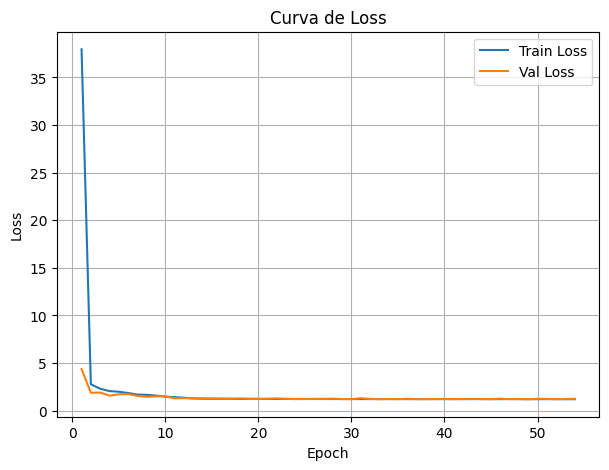

In [14]:
# ===============================
# 1) Gráfica de LOSS
# ===============================
plt.figure(figsize=(7,5))
plt.plot(hist['epoch'], hist['loss'], label="Train Loss")
plt.plot(hist['epoch'], hist['val_loss'], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Curva de Loss")
plt.legend()
plt.grid(True)
plt.show()